In [10]:
%matplotlib notebook

from Bio.PDB import PDBParser, NeighborSearch, Selection, Vector, vectors
import numpy as np
import itertools
import matplotlib.pyplot as plt
import matplotlib.colors as clr
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.cm as cm
import math
from math import sin, cos
from mpl_toolkits.mplot3d import proj3d
import pandas as pd
import os
##imports for 3d modelled graph
import plotly.graph_objects as go
from plotly.subplots import make_subplots

##imports for widgets (buttons that can be used to interact with the data)
from IPython.display import display
import ipywidgets as widgets
from ipywidgets import *

##imports for generating .edits file
import io
import sys

import matplotlib.animation as animation

import warnings
warnings.filterwarnings('ignore')

In [11]:
def angle(v1, v2,acute):
    # v1 is your first vector
    # v2 is your second vector
    angle = np.arccos(np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2)))
    if (acute == True):
        return angle * 57.2958
    else:
        return 2 * 57.2958 * np.pi - angle

def rotation_matrix_from_vectors(vec1, vec2):
    """ Find the rotation matrix that aligns vec1 to vec2
    :param vec1: A 3d "source" vector
    :param vec2: A 3d "destination" vector
    :return mat: A transform matrix (3x3) which when applied to vec1, aligns it with vec2.
    """
    a, b = (vec1 / np.linalg.norm(vec1)).reshape(3), (vec2 / np.linalg.norm(vec2)).reshape(3)
    v = np.cross(a, b)
    c = np.dot(a, b)
    s = np.linalg.norm(v)
    kmat = np.array([[0, -v[2], v[1]], [v[2], 0, -v[0]], [-v[1], v[0], 0]])
    rotation_matrix = np.eye(3) + kmat + kmat.dot(kmat) * ((1 - c) / (s ** 2))
    return rotation_matrix

#2d plotting function which displays a more minimalistic view of target atom and surroundings
def plotter_3d(contact_atom_coords,center_coord):
    
    fig = plt.figure(figsize=(5.5,5.5))
    ax = fig.add_subplot(projection = '3d')
    ax.set_axis_off()
    
    ax.axes.set_xlim3d(left= -1.75, right= 1.75) 
    ax.axes.set_ylim3d(bottom= -1.75, top= 1.75) 
    ax.axes.set_zlim3d(bottom= -1.75, top= 1.75) 
    
    ax.scatter(0,0,0, color = "tomato",s=100,marker = "P")
    
    # Plot H-BONDS AND THEIR COLORS ##############################################
    
    h_bond_dists = []

    for coord in contact_atom_coords:
        h_bond_dists.append('%.2f'%(math.dist(coord-center_coord,(0,0,0))))
    
    h_bond_dists = np.array(h_bond_dists, dtype=np.float64)
    
    c = clr.Normalize(2.2,3.5)
    
    mapper = cm.ScalarMappable(norm=c, cmap=cm.cool_r)
    
    i = 0
    
    for coord in contact_atom_coords:
        
        x = coord[0]-center_coord[0]
        y = coord[1]-center_coord[1]
        z = coord[2]-center_coord[2]
        

        im1, = ax.plot3D([x, 0], [y, 0], [z, 0], 
                  color = clr.to_hex(mapper.to_rgba(h_bond_dists[i])),
                  linestyle = 'dashed')

        #Conditional statements for displaying bond lengths and/or atom names
        if display_bond_lengths is True:
            ax.text((coord[0]-center_coord[0])*0.5,
                    (coord[1]-center_coord[1])*0.5,
                    (coord[2]-center_coord[2])*0.5,
                    str(h_bond_dists[i])+'Å')

        if display_atom_names is True:
            def extract_contact_atom_graphname(contact_atom_name):
                if isinstance(contact_atom_name, list) and len(contact_atom_name) > 0:
                    contact_atom_name = contact_atom_name[i]
                
                #Contact_atom_name[i] displays atom names in a very specific format. This splits that format and allows us to call whatever specific name we wnat
                CAN_split = contact_atom_name.split(' ')
                CAN_listname = CAN_split[0]
                CAN_resseq = CAN_split[2]
                CAN_resname = CAN_split[3]
                return CAN_listname, CAN_resseq, CAN_resname
        
            formatted_CAN_listname, formatted_CAN_resseq, formatted_CAN_resname = extract_contact_atom_graphname(contact_atom_name)
        
            ax.text(coord[0]-(1.003*center_coord[0]),
                    coord[1]-(1.003*center_coord[1]),
                    coord[2]-(0.997*center_coord[2]),
                    f'{formatted_CAN_listname}/{formatted_CAN_resname} {formatted_CAN_resseq}')
        
        i = i+1
    
    # Let's draw an ideal tetrahedron to superimpose over our water coordination network:
    # (±1,0,−1/2‾√),(0,±1,1/2‾√) are the coordinates of the vertices of the tetrahedron given a center at the origin
    # We'll rotate one of our vectors to align with a reference vector - which in this case is one of the H-bonding interactions
    
    matrix = rotation_matrix_from_vectors(np.array([1,0,-(2**-0.5)]),np.array([x,y,z]))
    vec1_rot = matrix.dot(np.array([1,0,-(2**-0.5)]))
    vec2_rot = matrix.dot(np.array([-1,0,-(2**-0.5)]))
    vec3_rot = matrix.dot(np.array([0,1,(2**-0.5)]))
    vec4_rot = matrix.dot(np.array([0,-1,(2**-0.5)]))
    
    im8, = ax.plot3D([vec1_rot[0], 0], [vec1_rot[1], 0], [vec1_rot[2], 0],color = 'black')
    im9, = ax.plot3D([vec2_rot[0], 0], [vec2_rot[1], 0], [vec2_rot[2], 0],color = 'black')
    im10, = ax.plot3D([vec3_rot[0], 0], [vec3_rot[1], 0], [vec3_rot[2], 0],color = 'black')
    im11, = ax.plot3D([vec4_rot[0], 0], [vec4_rot[1], 0], [vec4_rot[2], 0],color = 'black')
    
    #create an image that encompases the lines that will be toggled on and off by the "t" key (Relic of older code: doesn't seem to work)
    
    image_list = []
    
    image_list.append(im8)
    image_list.append(im9)
    image_list.append(im10)
    image_list.append(im11)
    
    i = 0
    for image in image_list:
        image.set_visible(False)
        
    def toggle_images(event):
        'toggle the visible state of the two images'
        if event.key != 't':
            return
        
        i = 0
        
        for image in image_list:
            image.set_visible(not image.get_visible())
        plt.draw()

    plt.connect('key_press_event', toggle_images)
    
    
    
    #change colorbar and its properties here ([left->right,up->down,width,height])
    mapper_axes = plt.gcf().add_axes([0.95, 0.15, 0.03, 0.7])
    
    plt.colorbar(mapper, cax=mapper_axes)
    
    #plt.savefig(input('plot name: '))
    plt.show()



In [12]:
#3d plotting function which gives us our interactive display. Uses plotly.graph_objects and can display bond lengths, angles, and atom names.
def interactive_plotter_3d(contact_atom_coords, center_coords):
    fig = go.Figure()
    axial_atoms = []
    equatorial_atoms = []
    contact_atoms_interactive = []
    markers = {}
    
    #subplots to overlay theoretical coordination geometries and observed coordination geometries on the same figure.
    fig = make_subplots(
        rows = 1, 
        cols = 2,
        subplot_titles=("Modelled atomic environment", "Hexagonal bipyramidal environment" if hexagonal_bipyramidal == True else " "),
        specs = [[{'type': 'scatter3d'}, {'type': 'scatter3d'}]],
        column_widths=[0.5,0.5] if hexagonal_bipyramidal == True else [1,0]
    )
    
    #adds x, y, and z vectors at the origin to help orient ourselves
    fig.add_trace(go.Scatter3d(
        x = [0, 0.5], y = [0, 0], z = [0, 0],
        mode = 'lines+text',
        line = dict(color = 'black'),
        text = [' ', 'x'],
        textposition = 'top center',
        hoverinfo = 'skip',
        showlegend = False
        ),
        row = 1,
        col = 1
    )
    
    fig.add_trace(go.Scatter3d(
        x = [0, 0], y = [0, 0.5], z = [0, 0],
        mode = 'lines+text',
        line = dict(color = 'black'),
        text = [' ', 'y'],
        textposition = 'top center',
        hoverinfo = 'skip',
        showlegend = False
        ),
        row = 1,
        col = 1
    )
    
    fig.add_trace(go.Scatter3d(
        x = [0, 0], y = [0, 0], z = [0, 0.5],
        mode = 'lines+text',
        line = dict(color = 'black'),
        text = [' ', 'z'],
        textposition = 'top center',
        hoverinfo = 'skip',
        showlegend = False
        ),
        row = 1,
        col = 1
    ) 
    
    #Atom display
    for i, coord in enumerate(contact_atom_coords):
        x = coord[0]-center_coord[0]
        y = coord[1]-center_coord[1]
        z = coord[2]-center_coord[2]
        distance = math.dist(coord - center_coord, (0,0,0))

        def extract_contact_atom_graphname(contact_atom_name):
            if isinstance(contact_atom_name, list) and len(contact_atom_name) > 0:
                contact_atom_name = contact_atom_name[i]

            CAN_split = contact_atom_name.split(' ')
            CAN_listname = CAN_split[0]
            CAN_resseq = CAN_split[2]
            CAN_resname = CAN_split[3]
            return CAN_listname, CAN_resseq, CAN_resname
        
        formatted_CAN_listname, formatted_CAN_resseq, formatted_CAN_resname = extract_contact_atom_graphname(contact_atom_name)
        
        graph_atom_name = f'{formatted_CAN_listname}/{formatted_CAN_resname} {formatted_CAN_resseq}'
        
        if graph_atom_name in [axial_atom1, axial_atom2]:               
            atom_shape = 'circle'
            atom_color_axial = 'darkblue'
            atom_color_equatorial = 'firebrick'
            axial_atoms.append(np.array([x, y, z]))

        else:
            equatorial_atoms.append(np.array([x, y, z]))
            atom_color_axial = 'blue'
            atom_color_equatorial = 'red'
            atom_shape = 'circle'
        
        #adds Hbond lines
        fig.add_trace(go.Scatter3d(
            x = [0, x],
            y  = [0, y],
            z = [0, z],
            mode = 'lines',
            line = dict(color = 'green', dash='dash'),
            name = f'{distance:.2f} Å',
            hoverinfo = 'skip'
            ),
            row = 1,
            col = 1
        ) 
        
        #add Hbond distances if desired
        fig.add_trace(go.Scatter3d(
            x = [x*.5],
            y = [y*.5],
            z = [z*.5],
            mode='text',
            text = f'{distance:.2f} Å' if display_bond_lengths == True else '',
            textposition = 'middle center',
            showlegend = False,
            hoverinfo = 'skip'
            ),
            row = 1,
            col = 1
        ) 
        
        #adds atoms
        fig.add_trace(go.Scatter3d(
            x = [x],
            y = [y],
            z = [z],
            mode = 'markers+text',
            marker = dict(color = atom_color_axial if toggle_axial_angle_display == True else atom_color_equatorial, size = 20, symbol = atom_shape),
            text = f'{formatted_CAN_listname}/{formatted_CAN_resname} {formatted_CAN_resseq}',
            name = f'{formatted_CAN_listname}/{formatted_CAN_resname} {formatted_CAN_resseq}',
            textposition = 'top center',
            hoverinfo = 'skip'
            ),
            row = 1,
            col = 1
        )
    
    #Code for adding equatorial or axial angle displays
    if len(axial_atoms) > 0 and toggle_axial_angle_display == True:
        for axial in axial_atoms:
            for equatorial in equatorial_atoms:
                angle_value = angle(axial, equatorial, acute=True)
                mid_x = (axial[0] + equatorial[0]) / 4
                mid_y = (axial[1] + equatorial[1]) / 4
                mid_z = (axial[2] + equatorial[2]) / 4

                fig.add_trace(go.Scatter3d(
                    x=[mid_x], y=[mid_y], z=[mid_z],
                    mode='text',
                    text=f'{angle_value:.2f}°',
                    textposition='middle center',
                    showlegend=False,
                    hoverinfo='skip'
                    ),
                    row = 1,
                    col = 1
                ) 
    
    if len(equatorial_atoms) > 0 and toggle_equatorial_angle_display == True:
        for i in range(len(equatorial_atoms)):
            for j in range(i + 1, len(equatorial_atoms)):
                eq_eq_angle = angle(np.array(equatorial_atoms[i]), np.array(equatorial_atoms[j]), acute=True)
                mid_x, mid_y, mid_z = np.add(np.array(equatorial_atoms[i]) / 4, np.array(equatorial_atoms[j]) /4)
                
                fig.add_trace(go.Scatter3d(
                    x=[mid_x], y=[mid_y], z=[mid_z],                       
                    mode='text', 
                    text=f'{eq_eq_angle:.1f}°',
                    textposition='middle center', 
                    showlegend=False,
                    hoverinfo='skip'
                    ),
                    row = 1,
                    col = 1
                )
    
    #coordination geometries. I've inputted a couple of simple coordination geometry displays for visual, side-by-side comparisons.
    if hexagonal_bipyramidal == True:
        
        fig.add_trace(go.Scatter3d(
            x = [0, 0],
            y = [0, 0],
            z = [-2.5, 2.5],
            mode = 'lines+text',
            line = dict(color = 'black'),
            text = [' ', ' '],
            textposition = 'top center',
            hoverinfo = 'skip',
            showlegend = False
            ),
            row = 1,
            col = 2
        )
        
        fig.add_trace(go.Scatter3d(
            x= [0, 0.2], y=[0, 0], z = [0, 0.2],                      
            mode='text', 
            text= [' ', '90°'],
            textposition='middle center', 
            showlegend=False,
            hoverinfo='skip'
            ),
            row = 1,
            col = 2
        )
        
        i = 0
        while i < 5:
            x_coord = 2.5 * np.cos((2*np.pi*i)/5)
            y_coord = 2.5 * np.sin((2*np.pi*i)/5)
            
            mid_x = (x_coord + (2.5 * np.cos((2*np.pi*(i+1))/5))) /5
            mid_y = (y_coord + (2.5 * np.sin((2*np.pi*(i+1))/5))) /5
            
            fig.add_trace(go.Scatter3d(
                x = [0, x_coord], y = [0, y_coord], z = [0, 0],
                mode = 'lines+text',
                line = dict(color = 'black'),
                text = [' ', ' '],
                textposition = 'top center',
                hoverinfo = 'skip',
                showlegend = False
                ),
                row = 1,
                col = 2
            )
            
            fig.add_trace(go.Scatter3d(
                x=[mid_x], y=[mid_y], z = [0, 0],                      
                mode='text', 
                text='72°',
                textposition='middle center', 
                showlegend=False,
                hoverinfo='skip'
                ),
                row = 1,
                col = 2
            )
            i = i + 1
    
    #sets the layout of the entire 3d graph
    fig.update_layout(
        width = 1250,
        height = 1250,
        hovermode='closest',
        scene1 = dict(
            xaxis = dict(title=' ', range=[target_atom_radius*1.2,target_atom_radius*-1.2], showbackground=False, showgrid=False, showline=False, zeroline=False, showticklabels=False, showspikes = False),
            yaxis = dict(title=' ', range=[target_atom_radius*1.2,target_atom_radius*-1.2], showbackground=False, showgrid=False, showline=False, zeroline=False, showticklabels=False, showspikes = False),
            zaxis = dict(title=' ', range=[target_atom_radius*1.2,target_atom_radius*-1.2], showbackground=False, showgrid=False, showline=False, zeroline=False, showticklabels=False, showspikes = False),
            camera = dict(eye=dict(x=1.5, y=1.5, z=1.5))
        ),
        scene2 = dict(
            camera=dict(eye=dict(x=1.5,y=1.5,z=1.5)),
            xaxis=dict(visible=False),
            yaxis=dict(visible=False),
            zaxis=dict(visible=False)
        )
    )
    
    fig.show()

In [13]:
#looks through our pdb file and pulls out selected atoms
def process_pdb(filepath,target_atom_id,chain_id):

    parser = PDBParser()

    structure = parser.get_structure("yup", filepath) # select the file to import

    chain_list = Selection.unfold_entities(structure, "C")
    
    all_atoms = []
    for chain in chain_list:
        for residue in chain:
            for atom in residue:
                if atom.is_disordered():
                    for conformer in atom.disordered_get_list():
                        all_atoms.append(conformer)
                else:
                    all_atoms.append(atom)
    
    i = 0
    for chain in chain_list: # figure out the index of the target chain in the pdb
        if chain.id == chain_id:
            chain_index = i
            break
        i = i + 1

    chain_atom_ids = []
        
    chain_atom_list = Selection.unfold_entities(chain_list[chain_index], "A") # creates a list of all atoms in target chain 

    atom_list = Selection.unfold_entities(chain_list, "A") # creates a list of all atoms in all chains
    
    for atom in chain_atom_list: 
        chain_atom_ids.append(atom.get_full_id()[4][0]+"_"+str(atom.get_full_id()[3][1]))
    
    target_atom = chain_atom_list[chain_atom_ids.index(str(target_atom_id))]
    center_coord = target_atom.coord

    distance_list = []
    vector_list = []

    residue_coords = {}
    residue_atoms = []

    cluster_atoms = []
    cluster_coords = []

    # Finds atoms within hydrogen bonding distance to the target atom
    contact_atoms = NeighborSearch(all_atoms).search(center = center_coord,radius = target_atom_radius,level = "A")

    # This statement removes the target atom itself from being considered a "contact" atom
    contact_atoms = [item for item in contact_atoms if item.coord[0] != center_coord[0] and 
                     item.coord[1] != center_coord[1] and item.coord[2] != center_coord[2]]   

    # for every atom, in contact_atoms, switch to preferred conformation. Remove any atoms that isn't in that conformation from our list 
    default_conformation = 'B'
    
    for atom in contact_atoms:
        
        disordered_atoms = []
        if atom.is_disordered() != 0:
            disordered_atoms.append(atom)

        for entry in disordered_atoms:
            #if the conformation hasn't been chosen, the program will tell you the possible conformations and then immediately switch to a default conformation
            if preferred_conformation == '' or preferred_conformation == ' ':
                print(entry.get_altloc() + ' this is a possible conformation of this atom ' )
                entry.set_altloc(default_conformation)
                print(entry.get_altloc() + " is the conformation we switched to")
                if default_conformation == 'A':
                    contact_atoms = [item for item in contact_atoms if item.get_altloc() != 'B']
                if default_conformation == 'B':
                    contact_atoms = [item for item in contact_atoms if item.get_altloc() != 'A']
            elif preferred_conformation == 'A':
                contact_atoms = [item for item in contact_atoms if item.get_altloc() != 'B']
            elif preferred_conformation == 'B':
                contact_atoms = [item for item in contact_atoms if item.get_altloc() != 'A']
            else:
                raise ValueError("Your preferred conformation doesn't match any possible conformations in the list! Please enter 'A', 'B', or '' ")

    contact_atom_coordinates = []
    contact_atom_name = []
    contact_atom_bfactor = []
    contact_atom_chain = []
    center_atom_name = target_atom.name
    center_atom_properties = target_atom.name + ' residue ' + target_atom.get_parent().get_resname() + ' ' + str(target_atom.get_full_id()[3][1]) + ' chain ' + str(target_atom.get_full_id()[2][0]) + ' and B-factor ' + str(target_atom.bfactor) + ' and occupancy ' + str(target_atom.occupancy)

    if len(contact_atoms) > 1:
        
        for contact in contact_atoms:

            if contact.element == 'O' or contact.element == 'N':

                    contact_atom_coordinates.append(contact.coord)
                    contact_atom_name.append(contact.name+
                                            ' residue '+contact.get_parent().get_resname()+
                                            " "+str(contact.get_full_id()[3][1]) +  ' chain ' + str(contact.get_full_id()[2][0]) + ' and B-factor ' + str(contact.bfactor))
                    contact_atom_bfactor.append(contact.bfactor)
                    contact_atom_chain.append(contact.get_full_id())

        
        #this entire part is used to generate a formatted .edits file for your use. Simply choose a directory and define some variables to have it automatically write a .edits file compatible with Phenix.refine
        
        #this function helps split the name of the target atom and its ID so that its formatted correctly for the .edits file
        def format_input_atom_and_number(target_atom_list):
            if isinstance(target_atom_list, list) and len(target_atom_list) > 0:
                target_atom_list = target_atom_list[0]
            
            parts = target_atom_list.split('_')
            target_atom_type = parts[0]
            target_atom_number = parts[1]
            return target_atom_type, target_atom_number
        
        formatted_atom, formatted_number = format_input_atom_and_number(target_atom_list)
        
        combined_text = []
        edits_header = 'refinement.geometry_restraints.edits {'
        combined_text.append(edits_header)
        edits_tail = '}'
        
        i = 0
        while i < len(contact_atom_coordinates):
            chosen_atom = contact_atoms[i]
            
            #this function helps isolate the name of the contact atoms' chain ID
            def extract_chain_ID(contact_atom_chain, index):
            
                elements = []
                for item in contact_atom_chain:
                    if isinstance(item, tuple) and len(item) > index:
                        elements.append(item[index])
                elements = elements[i]
                return elements
        
            chain_ID_index = 2
            contact_chain_ID = extract_chain_ID(contact_atom_chain, chain_ID_index)
        
            #this function isolates the atom name, resname, and resseq of each of the contact atoms
            def extract_contact_atom_properties(contact_atom_name):
                if isinstance(contact_atom_name, list) and len(contact_atom_name) > 0:
                    contact_atom_name = contact_atom_name[i]
                
                parts = contact_atom_name.split(' ')
                contact_atom_listname = parts[0]
                contact_atom_listresname = parts[2]
                contact_atom_listresseq = parts[3]
                return contact_atom_listname, contact_atom_listresname, contact_atom_listresseq
        
            formatted_listname, formatted_listresname, formatted_listresseq = extract_contact_atom_properties(contact_atom_name)
            
            if chosen_atom.is_disordered() != 0:
                formatted_altloc = ' and altloc '+chosen_atom.get_altloc()
            else:
                formatted_altloc = ''
            
            #Generates the iterative text for each atom
            bond_and_action = '  '+'bond {'+'\n'+'  '+'  '+'action = *add'
            target_atom_edits = '  '+'  ''atom_selection_1 = name '+formatted_atom+' and chain '+chain_id+' and resname'+target_atom.get_parent().get_resname()+' and resseq '+formatted_number
            contact_atom_edits = '  '+'  '+f'atom_selection_2 = name {formatted_listname} and chain {contact_chain_ID} and resname {formatted_listresname} and resseq {formatted_listresseq}'+formatted_altloc
            distance_and_sigma = '  '+'  '+'distance_ideal = '+str(ideal_bond_distance)+'\n'+'  '+'  '+'sigma = '+str(ideal_bond_distance_sd)
            
            combined_text.append(bond_and_action+'\n'+target_atom_edits+'\n'+contact_atom_edits+'\n'+distance_and_sigma+'\n'+'  '+'}')
                
            i = i+1
        
        combined_text.append(edits_tail)
        
        readable_edits_file = '\n'.join(combined_text)

        #put your desired directory here (for mac right click on folder, hold options key and click: Copy " " as Pathname:
        file_directory = "/Users/lbnl/Desktop/Jonathan Bright 2024 Desktop Files/EDITS files"
        #give a name to your file. Make sure that you make it a .edits file!
        file_name = "Sample_edits.txt"

        path_name = os.path.join(file_directory, file_name)

        os.makedirs(os.path.dirname(path_name), exist_ok=True)

        with open(path_name, "w") as file:
            file.write(readable_edits_file)

            """
            if (contact.get_parent().get_resname() != "OEZ"):

                    
            if (contact.get_parent().get_resname() == "OEZ"):

                if contact.element == 'O' or contact.element == 'N':

                    contact_atom_coordinates.append(contact.coord)
                    contact_atom_name.append(contact.name+
                                            ' of residue '+contact.get_parent().get_resname()+
                                            " "+str(contact.get_full_id()[3][1]))
            """
            
                    
    return contact_atom_coordinates,center_coord, contact_atom_name,center_atom_name, center_atom_properties, contact_atom_bfactor


In [14]:
def write_H_bonds(contact_atom_names,center_atom_name,contact_atom_coordinates,center_coord):
    
    h_bond_dists = []
    
    dictionary = {}
    
    for coord in contact_atom_coordinates:
        h_bond_dists.append('%.2f'%(math.dist(coord-center_coord,(0,0,0))))
    
    i = 0
    for name in contact_atom_names:
        dictionary[name] = float(h_bond_dists[i])
        i = i+1
    
    return dictionary


In [15]:
def construct_dataframe(dict_list,filenames):
    
    rows = []
    
    for dictionary in dict_list:
        rows = rows + list(dictionary.keys())
    
    rows = list(set(rows))
    
    df = pd.DataFrame(rows)
    
    i = 0
    
    for dictionary in dict_list:
        file_distances = []
        for label in rows:
            if label in dictionary.keys():
                file_distances.append(dictionary[label])
            else:
                file_distances.append(np.nan)

        df[filenames[i]] = file_distances
        i = i+1
 
    return df


In [16]:
#function that returns a list of angles between ligands
def bond_angles_func(contact_atom_coords,center_coord,contact_atom_name,center_atom_name):
    
    bond_combinations = []
    bond_angles = []
    atom_combinations = []
    
    for combination in itertools.combinations(contact_atom_coords-center_coord,2):
        bond_combinations.append(combination)
    
    for combination in itertools.combinations(contact_atom_name,2):
        atom_combinations.append(combination)

    for combination in bond_combinations:
        bond_angles.append(angle(combination[0],combination[1],True))
    
    #interactive button to display our angles in degrees
    degrees_button = widgets.Button(description="Angles in degrees")
    degrees_button_output = widgets.Output()
    
    def degrees_button_clicked(b):
        with degrees_button_output:
            i = 0
            while(i<len(bond_angles)):
                round_bond_angles = round(bond_angles[i], 2)
                print("the angle between: " + str(atom_combinations[i]) + ' in degrees is ' + str(round_bond_angles))
                i = i +1
            degrees_button.close()
            
    degrees_button.on_click(degrees_button_clicked)
    display(degrees_button, degrees_button_output)


# Using the Script

The user must provide a list of waters to observe, the directory containing the timepoint PDB files, and an output directory for the resulting excel files to be saved to.


PSII_Mn_Mediumlight_refine_016.pdb


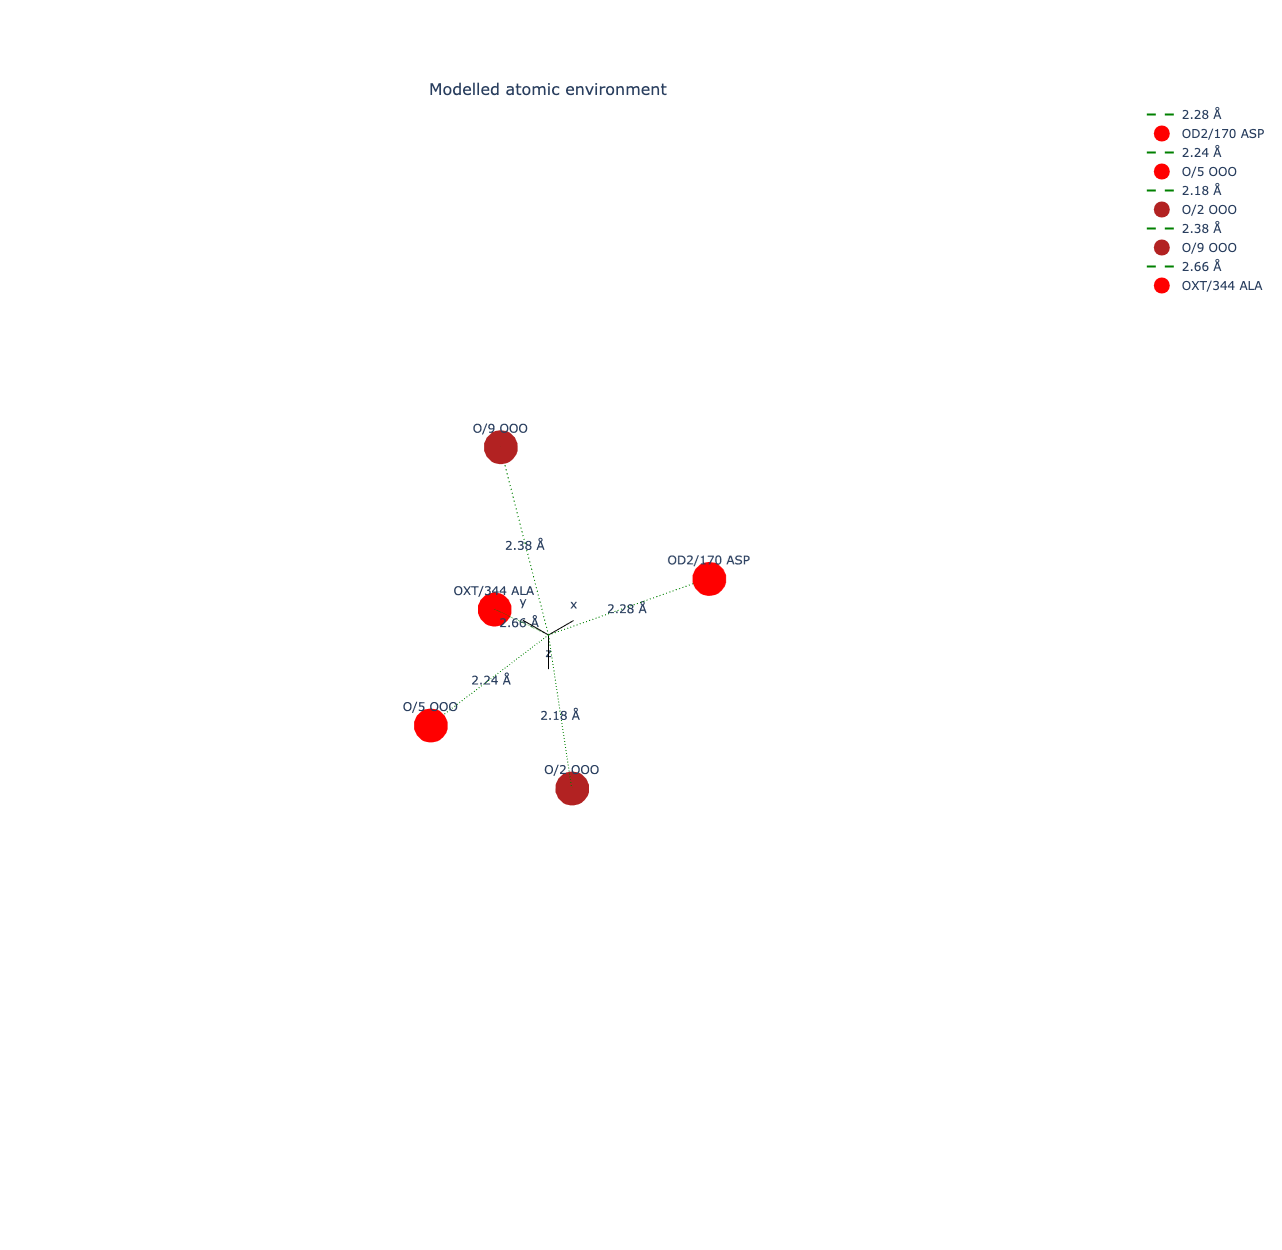

CA residue  CA 1 chain n and B-factor 46.93 and occupancy 0.65


Button(description='Angles in degrees', style=ButtonStyle())

Output()

In [19]:
%matplotlib inline
filenames = []
##choose your target_atom here and its respective chain ID
target_atom_list = ["Mn_1"]
chain_id = ""
target_atom_radius = 2.7
##leave preferred_conformation blank if you want the program to automatically choose the conformation it deems most appropriate
preferred_conformation = 'B'
##we'll use this for the .edits file. Put your ideal bond length depending on your target atom
ideal_bond_distance  = "2.400"
ideal_bond_distance_sd = "0.100"
##set either true or false depending on if you want a display for bond lengths, atom names, equatorial angles, or axial angles on the graphs
##Display sets all atoms to blue when choosing equatorial display to true. All atoms are chosen to be red in any other case.
display_atom_names = False
display_bond_lengths = True
toggle_axial_angle_display = False
toggle_equatorial_angle_display = False
##Coordination geometries to compare to
hexagonal_bipyramidal = False
##Temporary way of setting your axial atoms manually. Unfortunately iPywidgets seems to not mesh properly with Plotly. To be worked on in another patch.
axial_atom1 = "O/9 OOO"
axial_atom2 = "O/2 OOO"
#Axial atoms will be colored a darker color than their equatorial counterparts

for target_atom in target_atom_list:
    
    dict_list = []
    
    target_atom_name = target_atom

    directory_in_str = '/Users/lbnl/Desktop/PSII_Mn_Mediumlight/1Refine_mediumlight_darkside' #replace this with the directory containing your pdb files
    
    directory = os.fsencode(directory_in_str)

    for file in sorted(os.listdir(directory)):
        filename = os.fsdecode(file)
        if filename.endswith(".pdb"):
            
            print(filename)
            
            filepath = directory_in_str+'/'+filename
            
            contact_atom_coordinates, center_coord, contact_atom_name, center_atom_name, center_atom_properties, contact_atom_bfactor = process_pdb(filepath,target_atom_name,chain_id)


            h_bonds = write_H_bonds(contact_atom_name,center_atom_name,contact_atom_coordinates,center_coord)
            interactive_plotter_3d(contact_atom_coordinates,center_coord)
            dict_list.append(h_bonds)
            filenames.append(filename)
            df = construct_dataframe(dict_list,filenames)
            ##plotter_3d(contact_atom_coordinates,center_coord)
            dict_list.append(h_bonds)
            filenames.append(filename)
            df = construct_dataframe(dict_list,filenames)
            print(center_atom_properties)
            bond_angles_func(contact_atom_coordinates,center_coord,contact_atom_name,center_atom_name)
    #df.to_excel('/Users/albertqiang/Desktop/Yano Lab Work/water_'+str(water_name)+'bond_network.xlsx') # replace this with your output directory

In [ ]:
df

,0,PSII_Mn_Mediumlight_refine_016.pdb
0,O residue OOO 5 chain q and B-factor 43.11,2.24
1,OXT residue ALA 344 chain a and B-factor 48.28,2.66
2,OD2 residue ASP 170 chain a and B-factor 39.26,2.28
3,O residue OOO 9 chain q and B-factor 43.93,2.38
4,O residue OOO 2 chain q and B-factor 45.51,2.18
